# 4.3.多层感知机的简洁实现

本节将介绍**通过高级API更简洁地实现多层感知机**。
我们将 pypto 自定义 NPU 算子封装为 `nn.Module`，从而用 `nn.Sequential` 搭建模型——代码风格与 PyTorch 原生写法几乎一致。


---
## 环境配置


In [1]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('torch_npu.env').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor with interal format")
import pypto
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch_npu
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"

pypto.pypto_impl.DeviceInit()

# 从共享算子库导入 NPU 算子（定义见 ./src/pypto_ops.py，原理见 [4.2 节](./04.02_mlp_scratch.ipynb)）
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd, PyPTOReLUOp, loss_fn
from src.utils import plot


---
## 4.3.1.数据准备

与 [4.2 节](./04.02_mlp_scratch.ipynb) 相同，使用 Fashion-MNIST 数据集（28×28 灰度图，10 个类别），<code>batch_size = 256</code>。


In [2]:
batch_size = 256

trans = transforms.ToTensor()
mnist_train = datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
mnist_test = datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
train_iter = DataLoader(mnist_train, batch_size, shuffle=True, num_workers=0)
test_iter = DataLoader(mnist_test, batch_size, shuffle=False, num_workers=0)


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
import torch
from torch import nn
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
    </pre>

  </div>
</details>


---
## 4.3.2.复用 4.2 节的 NPU 算子

在 [4.2 节](./04.02_mlp_scratch.ipynb) 中，我们逐行编写了 matmul、bias_add、ReLU 的前向/反向 Kernel（用工厂模式封装），以及 softmax + 交叉熵的 4 个 Kernel（直接定义类）。那是「从零开始实现」的必要代价——只有把每个算子的内部机制摊开，才能看清 NPU 编程的底层细节。

本节关注的是**如何用高级 API（<code>nn.Module</code> + <code>nn.Sequential</code>）简洁地搭建 MLP**，而不是再讲一遍 Kernel。如果把 4.2 节那 ~170 行 Kernel 与工厂代码原样复制到这里，notebook 会变得又长又重复，反而把「简洁实现」这个主题稀释掉。

因此我们把 4.2 节的算子抽取到了一个共享模块 <code>./src/pypto_ops.py</code>，本节直接导入即可：

<table style="margin-left: 0; margin-right: auto; width: auto; text-align: left;">
  <tr>
    <th style="padding: 8px; text-align: left;">导入的算子</th>
    <th style="padding: 8px; text-align: left;">作用</th>
    <th style="padding: 8px; text-align: left;">对应 4.2 节的代码</th>
  </tr>
  <tr>
    <td style="padding: 8px;"><code>PyPTOMatmul</code></td>
    <td style="padding: 8px;">NPU 矩阵乘（带反向）</td>
    <td style="padding: 8px;">matmul 工厂 + 2 个 kernel</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><code>PyPTOBiasAdd</code></td>
    <td style="padding: 8px;">NPU 偏置加（带反向）</td>
    <td style="padding: 8px;">bias_add 工厂 + 2 个 kernel</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><code>PyPTOReLUOp</code></td>
    <td style="padding: 8px;">NPU ReLU（带反向）</td>
    <td style="padding: 8px;">relu 工厂 + 2 个 kernel</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><code>loss_fn</code></td>
    <td style="padding: 8px;">softmax + 交叉熵（带反向，<code>.mean()</code> 聚合）</td>
    <td style="padding: 8px;"><code>PyPTOSoftmaxCrossEntropyLossFunction</code> + 4 个 kernel</td>
  </tr>
</table>

**这些算子与 4.2 节功能等价**（kernel 实现完全一致；工厂封装做了少量整理，例如统一参数名、修正 bias 梯度的 squeeze）。想了解任意一个算子的前向/反向是怎么写的，随时可以回到 [4.2 节](./04.02_mlp_scratch.ipynb) 对照，或直接打开 [src/pypto_ops.py](./src/pypto_ops.py) 查看。

---
## 4.3.3.模型

将 NPU 算子封装为 `nn.Module` 后，即可用 `nn.Sequential` 简洁搭建——与 d2l 原文风格几乎一致。

<code>torch.autograd.Function</code> 在前向时调用 pypto kernel，反向时 PyTorch 自动触发对应的反向 kernel——梯度流对用户完全透明，使用方式与内置<code>nn.Linear</code> 完全一致。

回顾 [4.2 节](./04.02_mlp_scratch.ipynb)，你需要手写 ~170 行 pypto kernel + 工厂函数才能搭出一个 MLP。本节中，算子已经抽到 <code>src/pypto_ops.py</code>，同样的功能只需要 ~20 行业务代码（<code>nn.Module</code> 封装 + 训练循环），模型搭建和训练与 PyTorch 原生写法体验完全一致：

<table style="margin-left: 0; margin-right: auto; width: auto; text-align: left;">
  <tr>
    <th style="padding: 8px; text-align: left;">任务</th>
    <th style="padding: 8px; text-align: left;">04.02（从零实现）</th>
    <th style="padding: 8px; text-align: left;">04.03（简洁实现）</th>
  </tr>
  <tr>
    <td style="padding: 8px;">定义模型</td>
    <td style="padding: 8px;">kernel（~100 行）+ 工厂（~60 行）+ <code>def net(X)</code></td>
    <td style="padding: 8px;"><code>nn.Sequential(PyPTOLinear, PyPTOReLU, ...)</code></td>
  </tr>
  <tr>
    <td style="padding: 8px;">获取参数</td>
    <td style="padding: 8px;">手动维护 <code>params = [W1, b1, W2, b2]</code></td>
    <td style="padding: 8px;"><code>net.parameters()</code></td>
  </tr>
  <tr>
    <td style="padding: 8px;">移动到 NPU</td>
    <td style="padding: 8px;"><code>for p in params: p.data = p.data.to(device)</code></td>
    <td style="padding: 8px;"><code>net.to(device)</code></td>
  </tr>
  <tr>
    <td style="padding: 8px;">梯度清零（warmup）</td>
    <td style="padding: 8px;"><code>for p in params: p.grad = None</code></td>
    <td style="padding: 8px;"><code>net.zero_grad()</code></td>
  </tr>
  <tr>
    <td style="padding: 8px;">优化器初始化</td>
    <td style="padding: 8px;"><code>torch.optim.SGD(params, lr=lr)</code></td>
    <td style="padding: 8px;"><code>torch.optim.SGD(net.parameters(), lr=lr)</code></td>
  </tr>
</table>

### 4.3.3.1.将 NPU 算子封装为 `nn.Module`

在 [4.2 节](./04.02_mlp_scratch.ipynb) 中，我们需要手动调用 `PyPTOMatmul.apply(X, W)` 并把参数传给优化器——这套流程和 PyTorch 标准用法完全不同。在这里，我们把 NPU 算子封装为标准 `nn.Module`：

- `PyPTOLinear` 继承 `nn.Module` 的接口设计（`__init__` 定义权重/偏置，`forward` 定义前向计算），但其 `forward` 内部调用的是 NPU 上的 matmul + bias_add
- 也就是说：`PyPTOLinear` 的 `forward` 只有一行：

```python
PyPTOBiasAdd.apply(PyPTOMatmul.apply(x, self.weight), self.bias)
```

这行代码等价于 PyTorch `nn.Linear` 背后的 `X @ W + b`，只不过矩阵乘法和加法都发生在 NPU 上。封装之后，你完全不需要关心 NPU 的任何细节——你只是在用 `nn.Module` 搭网络。

In [3]:
class PyPTOLinear(nn.Module):
    # 用 NPU 矩阵乘 + 偏置加实现的全连接层
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(in_features, out_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return PyPTOBiasAdd.apply(PyPTOMatmul.apply(x, self.weight), self.bias)

class PyPTOReLU(nn.Module):
    # 用 NPU ReLU kernel 实现的激活层
    def forward(self, x):
        return PyPTOReLUOp.apply(x)

# 用 nn.Sequential 搭建，与 d2l 原文一一对应
net = nn.Sequential(
    nn.Flatten(),
    PyPTOLinear(784, 256),
    PyPTOReLU(),
    PyPTOLinear(256, 10)
)

# 将模型移到 NPU
net = net.to(device)
print(net)

# loss_fn 已从 src.pypto_ops 导入（softmax + 交叉熵，等价于 nn.CrossEntropyLoss(reduction='mean')）

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): PyPTOLinear()
  (2): PyPTOReLU()
  (3): PyPTOLinear()
)


<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><code>PyPTOLinear</code> 内部调用 <code>PyPTOMatmul.apply</code> + <code>PyPTOBiasAdd.apply</code>，等价于 d2l 原文的 <code>nn.Linear</code>（前向 <code>X @ W + b</code>）。</li>
      <li style="margin: 0 0 8px 0;"><code>PyPTOReLU</code> 调用 <code>PyPTOReLUOp.apply</code>，等价于 <code>nn.ReLU</code>。注意：src 中 ReLU 的 Function 类改名为 <code>PyPTOReLUOp</code>，把 <code>PyPTOReLU</code> 这个名字留给本节的 nn.Module 封装。</li>
      <li style="margin: 0 0 8px 0;">因为各层已封装为 <code>nn.Module</code>，可以用 <code>nn.Sequential</code> 搭建，训练时可调用 <code>net.parameters()</code> 获取所有参数。</li>
    </ul>
  </div>
</details>
<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights);
    </pre>

  </div>
</details>

## 4.3.4.训练

训练过程与 [4.2 节](./04.02_mlp_scratch.ipynb) 基本一致，只是参数管理从手动列表 <code>params</code> 换成了 <code>net.parameters()</code>。PyTorch 沿计算图自动调用各 `autograd.Function.backward()`，触发对应的 pypto 反向 kernel，梯度正确流入所有参数。

训练循环无需任何 NPU 相关改动——<code>loss.backward()</code> + <code>optimizer.step()</code> 自动驱动整个流程。**首次运行**会触发编译（约 6 分钟），编译完成后直接复用缓存。

训练输出中各指标含义：

- **损失**（loss）— 交叉熵损失值，衡量预测概率与真实标签之间的差异，值越低越好。
- **训练准确率** — 模型在当前训练集上分类正确的比例，用于判断模型是否在学习。
- **测试准确率** — 模型在未见过的测试集上的分类正确比例，用于判断**泛化能力**（如果训练准确率远高于测试准确率，则可能过拟合）。


**关于首次运行时间**

全部 10 个 kernel（matmul/bias_add/relu 各 2 个 + softmax/cross_entropy 各 2 个）在 **首次运行时** 需要编译器编译，大约耗时 **6 分钟**。编译只发生一次：编译完成后，后续所有迭代直接复用已编译的 kernel。


In [4]:
# 预热：触发所有 kernel 的首次编译（首次约 6 分钟）
print('正在编译 pypto kernel（首次运行需约 6 分钟，请耐心等待）...')
import time; t0 = time.time()
X, y = next(iter(train_iter))
X, y = X.to(device), y.to(device)
logits = net(X)
l = loss_fn(logits, y)
l.backward()
# 重置梯度，为正式训练做准备
net.zero_grad()
print(f'编译完成，耗时 {time.time()-t0:.0f} 秒。接下来可以正常训练了。')


正在编译 pypto kernel（首次运行需约 6 分钟，请耐心等待）...


编译完成，耗时 37 秒。接下来可以正常训练了。


In [5]:
num_epochs, lr = 10, 0.1
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

train_losses, test_accs = [], []
for epoch in range(num_epochs):
    train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        logits = net(X)
        l = loss_fn(logits, y)

        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        train_l_sum += l.item() * y.shape[0]
        train_acc_sum += (logits.argmax(dim=1) == y).float().sum().item()
        n += y.shape[0]

    train_losses.append(train_l_sum / n)
    # 评估测试集
    test_acc_sum, test_n = 0.0, 0
    with torch.no_grad():
        for X, y in test_iter:
            X, y = X.to(device), y.to(device)
            logits = net(X)
            test_acc_sum += (logits.argmax(dim=1) == y).float().sum().item()
            test_n += y.shape[0]
    test_acc = test_acc_sum / test_n
    test_accs.append(test_acc)

    print(f'第 {epoch + 1:2d} 轮, 损失 {train_l_sum / n:.4f}, '
          f'训练准确率 {train_acc_sum / n:.3f}, 测试准确率 {test_acc:.3f}')


第  1 轮, 损失 1.0486, 训练准确率 0.637, 测试准确率 0.715


第  2 轮, 损失 0.5962, 训练准确率 0.790, 测试准确率 0.786


第  3 轮, 损失 0.5180, 训练准确率 0.819, 测试准确率 0.795


第  4 轮, 损失 0.4807, 训练准确率 0.832, 测试准确率 0.827


第  5 轮, 损失 0.4524, 训练准确率 0.841, 测试准确率 0.833


第  6 轮, 损失 0.4331, 训练准确率 0.848, 测试准确率 0.837


第  7 轮, 损失 0.4143, 训练准确率 0.855, 测试准确率 0.843


第  8 轮, 损失 0.4053, 训练准确率 0.857, 测试准确率 0.841


第  9 轮, 损失 0.3912, 训练准确率 0.862, 测试准确率 0.841


第 10 轮, 损失 0.3807, 训练准确率 0.865, 测试准确率 0.852


<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
batch_size, lr, num_epochs = 256, 0.1, 10
loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=lr)

train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)
    </pre>

  </div>
</details>


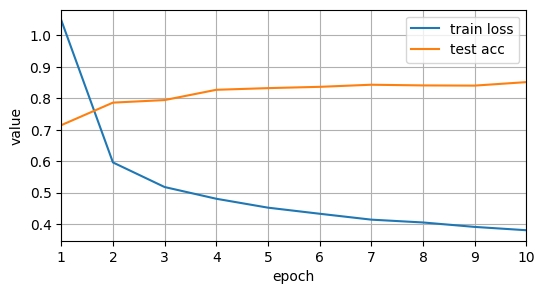

最终测试准确率: 0.852


In [6]:
# 绘制训练曲线（与 08/09 章一致的 d2l 风格：单轴，train loss 与 test acc 共用 y 轴）
plot(torch.arange(1, num_epochs + 1), [train_losses, test_accs], 'epoch',
     'value', legend=['train loss', 'test acc'], xlim=[1, num_epochs],
     figsize=(6, 3))

print(f'最终测试准确率: {test_accs[-1]:.3f}')


---
## 4.3.5.常见错误排查

<table style="margin-left: 0; margin-right: auto; width: auto; text-align: left;">
  <tr>
    <th style="padding: 8px; text-align: left;">现象</th>
    <th style="padding: 8px; text-align: left;">可能原因</th>
    <th style="padding: 8px; text-align: left;">解决方法</th>
  </tr>
  <tr>
    <td style="padding: 8px;">pypto kernel 编译/调用失败，报 <code>MemCopySync failed</code> 或 <code>aicpu exception</code></td>
    <td style="padding: 8px;">NPU 设备被其他进程占用</td>
    <td style="padding: 8px;">检查是否有残留 Python 进程占用 NPU：<code>ps aux | grep python</code>，杀掉残留进程后重试</td>
  </tr>
  <tr>
    <td style="padding: 8px;">首次运行 pypto kernel 时报错</td>
    <td style="padding: 8px;">未调用 <code>DeviceInit()</code> 初始化 pypto 运行时</td>
    <td style="padding: 8px;">确保 env 配置 cell 已完整执行（含 <code>pypto.pypto_impl.DeviceInit()</code>），该调用必须在任何 pypto Kernel 之前</td>
  </tr>
  <tr>
    <td style="padding: 8px;">训练准确率不提升，loss 波动异常</td>
    <td style="padding: 8px;">张量仍留在 CPU 上，未移到 NPU</td>
    <td style="padding: 8px;">确保数据通过 <code>.to(device)</code> 移到 NPU，参数也需一并移动（04.02 中手动 <code>p.data = p.data.to(device)</code>，04.03 中 <code>net.to(device)</code>）</td>
  </tr>
  <tr>
    <td style="padding: 8px;"><code>Reduce op: the tileShape of last axis need 32Byte align!</code></td>
    <td style="padding: 8px;">pypto tile shape 末维不是 32 字节的整数倍（如 10 个 FP32 = 40 bytes）</td>
    <td style="padding: 8px;">将 tile shape 末维改为 16 的倍数（如 <code>set_vec_tile_shapes(128, 16)</code>）</td>
  </tr>
  <tr>
    <td style="padding: 8px;">Kernel 首次运行等待很久（约 6 分钟）</td>
    <td style="padding: 8px;">首次运行触发编译器 JIT 编译，正常现象</td>
    <td style="padding: 8px;">耐心等待，编译结果会缓存（<code>output/</code> 目录），后续 epoch 不再等待</td>
  </tr>
</table>

## 4.3.6.小结

学完本节，你已经掌握了 pypto 开发的完整管线，从底到顶共四层：
1. **pypto Kernel**（`@pypto.frontend.jit`）—— 最底层，定义 NPU 上的计算。
2. **`torch.autograd.Function`** —— 桥接层，连接 pypto Kernel 与 PyTorch 自动微分。
3. **`nn.Module`** —— 用户层，将 Function 封装为标准模块（本节的重点）。
4. **`nn.Sequential` + 标准训练循环** —— 应用层，与 PyTorch 原生写法完全一致。

第 1、2 层在 [4.2 节](./04.02_mlp_scratch.ipynb) 中逐行讲透后，已收进 <code>src/pypto_ops.py</code> 供本章复用；本节在第 3、4 层上做文章——用 <code>net.parameters()</code>、<code>net.to(device)</code>、<code>optimizer.zero_grad()</code>、<code>optimizer.step()</code> 这些标准 API 驱动 NPU 上的训练，体验与 PyTorch 原生写法无异。
## 4.3.7.练习

1. 尝试添加不同数量的隐藏层（也可以修改学习率），怎么样设置效果最好？
2. 尝试不同的激活函数（如 sigmoid、tanh，参考 [4.1 节](./04.01_mlp.ipynb) 的 kernel 实现），哪个效果最好？（提示：sigmoid/tanh 的 kernel 未收入 `src/pypto_ops.py`，需要从 4.1 节复制 kernel 并自行封装为 nn.Module。）
3. 尝试不同的方案来初始化权重，什么方法效果最好？

参考答案详见 [answers/04.03_reference_answer](./answers/04.03_reference_answer.ipynb)。


### 参考答案（PyPTO）

In [7]:
!cat answers/txt/04.03_reference_answer_pypto.txt

### 参考答案（PyTorch）

In [8]:
!cat answers/txt/04.03_reference_answer_pytorch.txt